In [1]:
# ============================================================
# ライブラリの import
# ============================================================
import torch
import torch.nn as nn          # 層の定義（Linear, ReLU など）
import torch.optim as optim    # 最適化（Adam など）

from torch.utils.data import DataLoader          # ミニバッチでデータを流す
# from torchvision import datasets, transforms     # MNIST と前処理

#  FashionMNIST は モジュールではなくクラス
# "from torchvision.datasets.FashionMNIST import datasets,transforms

# いったんこっちを採用
from torchvision import datasets, transforms
# 使うとき: datasets.FashionMNIST(...)

# from torchvision.datasets import FashionMNIST
# from torchvision import transforms
# 使うとき: FashionMNIST(...)

In [2]:
# ============================================================
# デバイス選択（GPU があれば cuda、なければ cpu）
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
# 今の環境は CPU でも MNIST MLP なら数分で学習できる

device: cuda


In [3]:
from pathlib import Path


def find_project_root(start_path: Path) -> Path:
    """
    上位ディレクトリを探索し、
    .gitが存在する場所をプロジェクトルートとして返す。
    """
    start_path = start_path.resolve()

    for candidate in [
        start_path,
        *start_path.parents,
    ]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError(
        "プロジェクトルートを特定できませんでした。"
        "上位ディレクトリに.gitが存在するか確認してください。"
    )


# プロジェクトルートを取得
project_root = find_project_root(Path.cwd())

# 実験を識別する名前
dataset_name = "20_fashion_mnist"
experiment_name = "00_mlp_baseline_fixed_50epochs"

# プロジェクトルート直下へ保存する
data_dir = project_root / "data"

# NG（旧）: models は dataset 直下にフラット保存
# models_dir = (
#     project_root
#     / "models"
#     / dataset_name
# )
# OK: results と同じく experiment_name ディレクトリに分ける
models_dir = (
    project_root
    / "models"
    / dataset_name
    / experiment_name
)

results_dir = (
    project_root
    / "results"
    / dataset_name
    / experiment_name
)

# 必要なディレクトリを作成する
for directory in [
    data_dir,
    models_dir,
    results_dir,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(f"project_root: {project_root}")
print(f"data_dir:     {data_dir}")
print(f"models_dir:   {models_dir}")
print(f"results_dir:  {results_dir}")

project_root: D:\dev\nn-compression-svd-dmrg
data_dir:     D:\dev\nn-compression-svd-dmrg\data
models_dir:   D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\00_mlp_baseline_fixed_50epochs
results_dir:  D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\00_mlp_baseline_fixed_50epochs


In [4]:
# ============================================================
# FashionMNIST データの準備
# ============================================================
# ToTensor(): 画像を [0,1] の float テンソルに変換
#   元: PIL Image (28×28) → 後: Tensor (1, 28, 28)
transform = transforms.Compose([
    transforms.ToTensor()
])

# root="./data" にダウンロード＆キャッシュされる
train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

# DataLoader: データをミニバッチに分割して渡す
train_loader = DataLoader(
    train_dataset,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=True     # 学習時は順番を混ぜる
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False    # 評価時は混ぜなくてよい
)

print("train size:", len(train_dataset))  # 60000（規定値）
print("test size:", len(test_dataset))    # 10000（規定値）

train size: 60000
test size: 10000


In [5]:
# ============================================================
# MLP の定義（圧縮前のベースライン構造）
# ============================================================
# 784 → 512 → 256 → 10
# あとで fc1 / fc2 の重みを SVD で圧縮する想定
class MNISTMLP(nn.Module):
    # 
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)  # ここが圧縮の主な対象候補
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(256, 10)   # 出力は 10 クラス（数字 0〜9）

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28)

        #-1→ 残りの次元を自動で計算する。
        # if self.training:
        # ...
        # else:
        # ...
        # 画像を1次元ベクトルに変換（MLP はベクトル入力）
        # x.size(0)→ バッチサイズ(64)をそのまま残す。
        x = x.view(x.size(0), -1)  # (batch_size, 784)

        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)  # logits（ソフトマックス前の生スコア）を返す

        return x

In [6]:
# ============================================================
# モデル・損失関数・最適化手法の準備
# ============================================================

# MNISTMLP() で、さっき定義したニューラルネット本体を作っています。
# .to(device) は、そのモデルをGPU に移しています。
model = MNISTMLP().to(device)

# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

# Adam: 学習率 0.001 はよく使う初期値
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MNISTMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [7]:
# ============================================================
# 学習 1 epoch = 「全データを1回見て、間違いを直す」
# ============================================================
# 1バッチごとのやること（これが学習の本体）:
#   1. 画像を入れる → 予測が出る
#   2. 正解と比べて loss（間違い）を計算
#   3. 「どの重みをどう直せばいいか」を計算（backward）
#   4. 重みを少し更新（step）
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    # model.train() は nn.Module が持っている仕組み
    # モデル自身とその子モジュールの training 状態を True にします
    # 今はなくてもあっても変わらない
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  # 64枚ずつ取り出す
        images = images.to(device)
        labels = labels.to(device)

        # PyTorch は勾配を足し込むので、毎回リセット
        optimizer.zero_grad()            # ① 前回の修正メモを消す

        # forwardを使って計算している
        # outputs = model.forward(images)と同じ
        outputs = model(images)          # ② 予測（10クラス分のスコア）

        loss = criterion(outputs, labels)  # ③ 間違いの大きさ

        # 誤差逆伝播をして勾配を作る
        # forwardで計算したlossをbackwardで勾配を計算する
        loss.backward()                  # ④ どこを直せばいいか計算

        # backwardで計算した勾配をstepで更新する
        optimizer.step()                 # ⑤ 重みを少し直す

        # loss.item() はそのバッチの平均損失
        # images.size(0) を掛けるのは、64枚分の損失の合計っぽいものに直して、
        # あとで全体平均を取るため
        total_loss += loss.item() * images.size(0)

        # 0~9での各スコアを比較して１番大きいものをとる→これが予測
        predicted = torch.argmax(outputs, dim=1)  # 一番高いスコアの数字

        # 予測と正解を比較して、正解している数を数える
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total   # 平均 loss
    accuracy = correct / total      # 正解率

    return avg_loss, accuracy

In [8]:
# ============================================================
# テストデータでの評価（学習はしない）
# ============================================================
def evaluate(model, test_loader, criterion, device):
    model.eval()  # 評価モード

    total_loss = 0.0
    correct = 0
    total = 0

    # 評価時は勾配不要 → メモリ節約・高速化
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [9]:
# ============================================================
# 学習ループ（10 epoch）
# ============================================================
# 目安: Test Acc が 97〜98% くらいまで上がれば OK
num_epochs = 50

results = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )
    row = {
    "epoch": epoch,
    "train_acc":train_acc,
    "train_loss": train_loss,
    "test_loss": test_loss,
    "test_acc": test_acc,
    }
    results.append(row)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Test Loss: {test_loss:.4f}, "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch [1/50] Train Loss: 0.4983, Train Acc: 0.8193, Test Loss: 0.4186, Test Acc: 0.8471
Epoch [2/50] Train Loss: 0.3595, Train Acc: 0.8681, Test Loss: 0.3743, Test Acc: 0.8637
Epoch [3/50] Train Loss: 0.3207, Train Acc: 0.8818, Test Loss: 0.3591, Test Acc: 0.8699
Epoch [4/50] Train Loss: 0.2985, Train Acc: 0.8878, Test Loss: 0.3432, Test Acc: 0.8802
Epoch [5/50] Train Loss: 0.2779, Train Acc: 0.8960, Test Loss: 0.3562, Test Acc: 0.8643
Epoch [6/50] Train Loss: 0.2643, Train Acc: 0.9008, Test Loss: 0.3395, Test Acc: 0.8780
Epoch [7/50] Train Loss: 0.2491, Train Acc: 0.9053, Test Loss: 0.3174, Test Acc: 0.8885
Epoch [8/50] Train Loss: 0.2398, Train Acc: 0.9085, Test Loss: 0.3283, Test Acc: 0.8821
Epoch [9/50] Train Loss: 0.2270, Train Acc: 0.9138, Test Loss: 0.3233, Test Acc: 0.8896
Epoch [10/50] Train Loss: 0.2176, Train Acc: 0.9174, Test Loss: 0.3830, Test Acc: 0.8788
Epoch [11/50] Train Loss: 0.2097, Train Acc: 0.9194, Test Loss: 0.3249, Test Acc: 0.8881
Epoch [12/50] Train Loss: 0.19

In [10]:
import pandas as pd

# list[dict] → DataFrame（この形がグラフ・集計に一番使いやすい）
df_results = pd.DataFrame(results)
# 見やすい表示用に丸める（元の df_results は生の数値のまま残す）
df_view = df_results.copy()
df_view["epoch"] = df_view["epoch"].astype(int)
df_view["test_loss"] = df_view["test_loss"].round(4)
df_view["test_acc"] = df_view["test_acc"].round(4)
df_view["train_loss"] = df_view["train_loss"].round(4)
df_view["train_acc"] = df_view["train_acc"].round(4)

print(df_view)



    epoch  train_acc  train_loss  test_loss  test_acc
0       0     0.8193      0.4983     0.4186    0.8471
1       1     0.8681      0.3595     0.3743    0.8637
2       2     0.8818      0.3207     0.3591    0.8699
3       3     0.8878      0.2985     0.3432    0.8802
4       4     0.8960      0.2779     0.3562    0.8643
5       5     0.9008      0.2643     0.3395    0.8780
6       6     0.9053      0.2491     0.3174    0.8885
7       7     0.9085      0.2398     0.3283    0.8821
8       8     0.9138      0.2270     0.3233    0.8896
9       9     0.9174      0.2176     0.3830    0.8788
10     10     0.9194      0.2097     0.3249    0.8881
11     11     0.9240      0.1978     0.3327    0.8926
12     12     0.9264      0.1909     0.3751    0.8847
13     13     0.9294      0.1827     0.3374    0.8929
14     14     0.9317      0.1762     0.3487    0.8880
15     15     0.9332      0.1721     0.3541    0.8972
16     16     0.9377      0.1631     0.3595    0.8981
17     17     0.9395      0.

saved: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\00_mlp_baseline_fixed_50epochs\overfitting.png


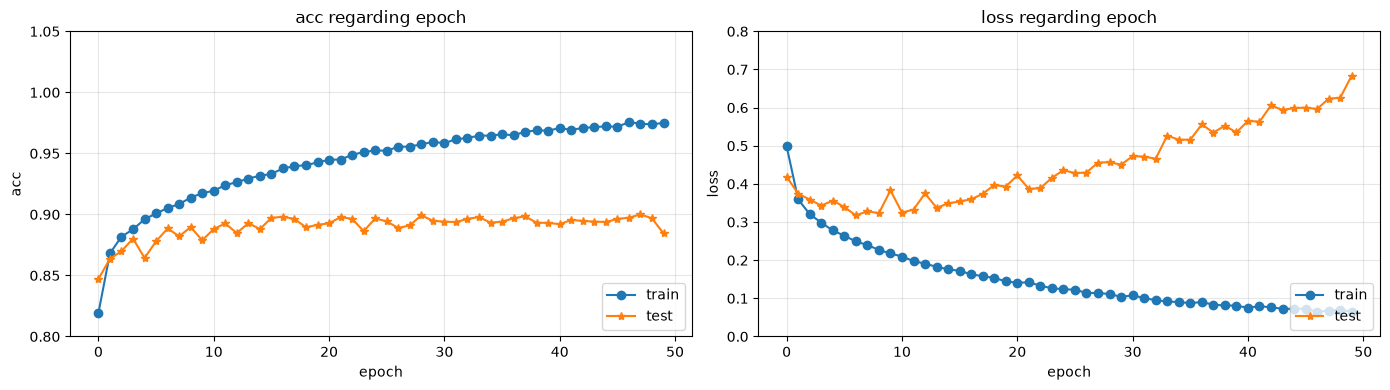

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path(results_dir)
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1)acc
axes[0].plot(
    df_view["epoch"],
    df_view["train_acc"],
    marker="o",
)

axes[0].plot(
    df_view["epoch"],
    df_view["test_acc"],
    marker="*",
)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("acc")
axes[0].set_ylim(0.8, 1.05)
axes[0].set_title("acc regarding epoch")
axes[0].grid(True, alpha=0.3)
axes[0].legend(["train", "test"], loc="lower right")


# 1)loss
axes[1].plot(
    df_view["epoch"],
    df_view["train_loss"],
    marker="o",
)

axes[1].plot(
    df_view["epoch"],
    df_view["test_loss"],
    marker="*",
)

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_ylim(0.0, 0.8)
axes[1].set_title("loss regarding epoch")
axes[1].grid(True, alpha=0.3)
axes[1].legend(["train", "test"], loc="lower right")

plt.tight_layout()
energy_path = out_dir / "overfitting.png"
fig.savefig(energy_path, dpi=150, bbox_inches="tight")
print("saved:", energy_path.resolve())
plt.show()

In [12]:
# ============================================================
# パラメータ数を数える（圧縮後と比較する基準）
# ============================================================
# fc1: 784*512+512 = 401,920
# fc2: 512*256+256 = 131,328
# fc3: 256*10+10   =   2,570
# 合計             = 535,818
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(model)
print("Baseline params:", baseline_params)

Baseline params: 535818


In [13]:
# ============================================================
# 学習済み重みを保存（次のノートで読み込んで SVD 圧縮する）
# ============================================================
# state_dict = 各層の weight / bias だけを辞書で保存
df_results.to_csv(
    results_dir/"00_mlp_baseline_fixed_50epochs_history.csv",
    index=False,
)
# 最良モデルの保存先
model_path = (
    models_dir
    / "00_mlp_baseline_fixed_50epochs.pt"
)

torch.save(
    model.state_dict(),
    model_path,
)

# 学習履歴の保存先
history_path = results_dir / "history.csv"

df_results.to_csv(
    history_path,
    index=False,
)

# 学習曲線の保存先
figure_path = results_dir / "learning_curves.png"

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

print(f"saved model:   {model_path}")
print(f"saved history: {history_path}")
print(f"saved figure:  {figure_path}")

saved model:   D:\dev\nn-compression-svd-dmrg\models\20_fashion_mnist\00_mlp_baseline_fixed_50epochs\00_mlp_baseline_fixed_50epochs.pt
saved history: D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\00_mlp_baseline_fixed_50epochs\history.csv
saved figure:  D:\dev\nn-compression-svd-dmrg\results\20_fashion_mnist\00_mlp_baseline_fixed_50epochs\learning_curves.png


In [14]:
print(
    globals().get(
        "__vsc_ipynb_file__",
        "取得できません",
    )
)
 


d:\dev\nn-compression-svd-dmrg\notebooks\20_fashion_mnist\mlp\00_mlp_baseline_fixed_50epochs.ipynb
